In [1]:
import torch

# for data from iterative_rewiring_2.py


In [2]:
DATA_DIR = '/teamspace/studios/this_studio/Over_Squashing_GNNs/gnn-comparison/DATA/'
DATA = torch.load(DATA_DIR + 'ENZYMES_100.pt')

# For data from Exp2.py


In [2]:
DATA = torch.load("/teamspace/studios/this_studio/Over_Squashing_GNNs/gnn-comparison/DATA/CHEMICAL/ENZYMES_rewired_seed42/ENZYMES_100pct_seed42.pt")

In [13]:
666*2

1332

In [3]:
DATA

[Data(edge_index=[2, 168], x=[37, 21], y=[1], rewired_edge_index=[2, 1332]),
 Data(edge_index=[2, 102], x=[23, 21], y=[1], rewired_edge_index=[2, 506]),
 Data(edge_index=[2, 92], x=[25, 21], y=[1], rewired_edge_index=[2, 600]),
 Data(edge_index=[2, 90], x=[24, 21], y=[1], rewired_edge_index=[2, 552]),
 Data(edge_index=[2, 90], x=[23, 21], y=[1], rewired_edge_index=[2, 506]),
 Data(edge_index=[2, 92], x=[24, 21], y=[1], rewired_edge_index=[2, 552]),
 Data(edge_index=[2, 118], x=[26, 21], y=[1], rewired_edge_index=[2, 650]),
 Data(edge_index=[2, 266], x=[88, 21], y=[1], rewired_edge_index=[2, 7656]),
 Data(edge_index=[2, 78], x=[23, 21], y=[1], rewired_edge_index=[2, 506]),
 Data(edge_index=[2, 106], x=[32, 21], y=[1], rewired_edge_index=[2, 992]),
 Data(edge_index=[2, 12], x=[4, 21], y=[1], rewired_edge_index=[2, 12]),
 Data(edge_index=[2, 56], x=[14, 21], y=[1], rewired_edge_index=[2, 182]),
 Data(edge_index=[2, 150], x=[42, 21], y=[1], rewired_edge_index=[2, 1722]),
 Data(edge_index=[

In [4]:
DATA[10]

Data(edge_index=[2, 12], x=[4, 21], y=[1], rewired_edge_index=[2, 12])

# should print nothing


In [ ]:
j = 0
for i in DATA:
   N =  i.x.size(0)
   temp = int((N *(N-1)))
   if i.rewired_edge_index.size(1) != temp:
    print(j)
    #print(N, i.rewired_edge_index.size(1),temp)
    print(f"{N} nodes | {i.rewired_edge_index.size(1)} edges | {temp} possible edges")
    
   j += 1

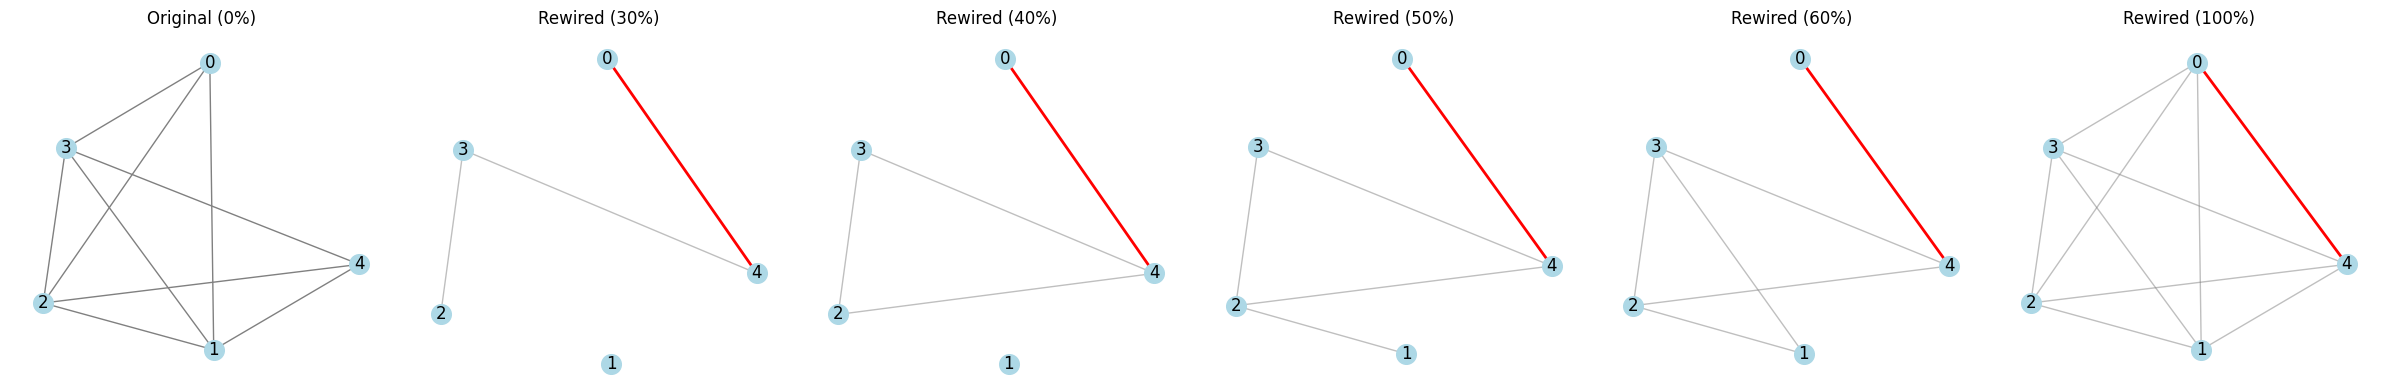

In [8]:
import torch
import os
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

# ================= CONFIGURATION =================
# Path to the folder containing your .pt files
DATA_DIR = '/teamspace/studios/this_studio/Over_Squashing_GNNs/gnn-comparison/DATA/CHEMICAL/'
DATASET_NAME = 'ENZYMES'
GRAPH_ID = 99 # Pick a graph index (e.g., 0 to 599 for ENZYMES)
PERCENTAGES = [30, 40, 50, 60, 100] # The files you generated
# =================================================

def load_file(p):
    filename = f"{DATASET_NAME}_{p}.pt"
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Warning: File {filename} not found.")
        return None
    return torch.load(path)

def visualize_evolution(graph_id):
    # 1. Setup the plot
    num_plots = len(PERCENTAGES) + 1 # +1 for the Original baseline
    fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))
    
    # 2. Get Baseline (Original Graph) from the first available file
    # We use the 30% file, but access data.edge_index (which your script preserved as original)
    baseline_data_list = load_file(PERCENTAGES[0])
    if baseline_data_list is None: return
    
    baseline_data = baseline_data_list[graph_id]
    
    # Convert to NetworkX
    # We use the 'canonical' edge_index, which your script ensured was the original structure
    G_orig = to_networkx(baseline_data, to_undirected=True)
    
    # Calculate fixed position layout so nodes don't jump around
    pos = nx.spring_layout(G_orig, seed=42) 
    
    # --- Plot 1: Original Graph ---
    ax = axes[0]
    nx.draw(G_orig, pos, ax=ax, with_labels=True, node_color='lightblue', 
            node_size=200, edge_color='grey', width=1.0)
    ax.set_title("Original (0%)")
    
    # Store original edges set for comparison (frozenset for undirected comparison)
    # We sort the tuple so (0,1) is same as (1,0)
    orig_edges = set([frozenset(e) for e in G_orig.edges()])

    # 3. Loop through Rewired Files
    for i, p in enumerate(PERCENTAGES):
        ax = axes[i + 1]
        
        # Load the specific percentage file
        data_list = load_file(p)
        if data_list is None: continue
            
        data = data_list[graph_id]
        
        # Create a temporary Data object with the REWIRED edges to convert to NetworkX
        # (Since to_networkx uses .edge_index by default)
        data_rewired = data.clone()
        data_rewired.edge_index = data.rewired_edge_index
        
        G_rewired = to_networkx(data_rewired, to_undirected=True)
        
        # Separate edges into "Old" (Grey) and "New" (Red)
        edges_all = G_rewired.edges()
        edges_new = []
        edges_kept = []
        
        for e in edges_all:
            if frozenset(e) in orig_edges:
                edges_kept.append(e)
            else:
                edges_new.append(e)
        
        # Draw Nodes
        nx.draw_networkx_nodes(G_rewired, pos, ax=ax, node_color='lightblue', node_size=200)
        nx.draw_networkx_labels(G_rewired, pos, ax=ax)
        
        # Draw Original Edges (Grey)
        nx.draw_networkx_edges(G_rewired, pos, ax=ax, edgelist=edges_kept, 
                               edge_color='grey', width=1.0, alpha=0.5)
        
        # Draw NEW Rewired Edges (Red)
        if edges_new:
            nx.draw_networkx_edges(G_rewired, pos, ax=ax, edgelist=edges_new, 
                                   edge_color='red', width=2.0)
            
        ax.set_title(f"Rewired ({p}%)")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualizer


visualize_evolution(GRAPH_ID)

In [ ]:
import torch
import os
import pandas as pd
import numpy as np

# change directory and string names to adapt to exp_2.py data

In [6]:
import torch
import os
import pandas as pd
import numpy as np

# ================= CONFIGURATION =================
DATA_DIR = '/teamspace/studios/this_studio/Over_Squashing_GNNs/gnn-comparison/DATA/CHEMICAL/'
DATASET_NAME = 'ENZYMES'
PERCENTAGES = [30, 40, 50, 60, 70, 80, 90, 100]
CHECK_GRAPH_IDS = [0, 5, 10, 50, 100] 
# =================================================

def load_file(p):
    filename = f"{DATASET_NAME}_{p}.pt"
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Warning: File {filename} not found at {path}")
        return None
    return torch.load(path)

def get_edges_set(edge_index):
    """
    Converts PyG edge_index into a set of directed tuples (u, v).
    Filters out self-loops to verify the sampling logic strictly.
    """
    if edge_index.dim() != 2 or edge_index.size(1) == 0:
        return set()
    
    edge_list = edge_index.t().tolist()
    # PRESERVE DIRECTION: (u, v) != (v, u) because our sampler is directed
    # FILTER LOOPS: We verify the % of non-loop edges only
    return set((u, v) for u, v in edge_list if u != v)

def verify_cumulative_rewiring():
    results = []
    
    print(f"Loading datasets from {DATA_DIR}...")
    datasets = {}
    for p in PERCENTAGES:
        ds = load_file(p)
        if ds: datasets[p] = ds

    if not datasets: 
        print("No datasets loaded. Aborting.")
        return

    print(f"Verifying graphs: {CHECK_GRAPH_IDS}")

    for graph_id in CHECK_GRAPH_IDS:
        # Safety check: Ensure graph ID exists
        first_dataset_list = list(datasets.values())[0]
        if graph_id >= len(first_dataset_list):
            print(f"Graph ID {graph_id} out of bounds.")
            continue

        # Get Baseline N from the first available dataset
        first_data = first_dataset_list[graph_id]
        N = first_data.num_nodes
        
        # Max capacity for DIRECTED non-loop edges
        max_possible_edges = N * (N - 1)

        row = {
            'ID': graph_id,
            'N': N,
            'Capacity': max_possible_edges
        }

        previous_set = None
        
        for p in PERCENTAGES:
            if p not in datasets:
                continue
                
            data = datasets[p][graph_id]
            
            # Use rewired_edge_index if available (this is what we just generated)
            edges_to_check = data.rewired_edge_index if hasattr(data, 'rewired_edge_index') else data.edge_index
            
            # Get clean set of directed edges (no self-loops)
            current_set = get_edges_set(edges_to_check)
            count = len(current_set)
            
            # 1. Check Monotonicity (Is subset?)
            if previous_set is not None:
                is_subset = previous_set.issubset(current_set)
                diff = count - len(previous_set)
            else:
                is_subset = True
                diff = count

            # 2. Check Target Math
            expected_count = int(max_possible_edges * (p / 100.0))
            
            # Handle Edge Case: If p > 0, we generally expect at least 1 edge if capacity allows
            # (Matches the 'min(needed, num_candidates)' logic in your sampler if rounding goes to 0)
            if max_possible_edges > 0 and expected_count == 0:
                # Note: If your sampler STRICTLY follows int(), keep expected at 0.
                # If you adjusted it to ensure >0, set to 1. 
                # Based on your previous 'int' logic, it likely stays 0 until math hits 1.
                pass 
            
            # Verify match
            # "Full" check handles cases where count == capacity (100% saturation)
            if count == expected_count: 
                match_symbol = "✅"
            elif count == max_possible_edges and expected_count >= max_possible_edges:
                match_symbol = "✅(Full)"
            else:
                match_symbol = f"⚠️({count}/{expected_count})"
            
            # Store short summaries for the table
            row[f'{p}% Count'] = count
            row[f'{p}% Diff'] = f"+{diff}"
            row[f'{p}% OK?'] = match_symbol
            
            previous_set = current_set

        results.append(row)

    # Display
    df = pd.DataFrame(results)
    print("\n" + "="*50)
    print("EDGE REWIRING VERIFICATION REPORT (DIRECTED)")
    print("Capacity = N * (N-1) | Count excludes self-loops")
    print("="*50)
    
    # Pretty print options
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    display(df) # Use display(df) in Jupyter, print(df) in script
    
    # Save to CSV
    df.to_csv('verification_results.csv', index=False)
    print("\nSaved detailed results to 'verification_results.csv'")

if __name__ == "__main__":
    verify_cumulative_rewiring()

Loading datasets from /teamspace/studios/this_studio/Over_Squashing_GNNs/gnn-comparison/DATA/CHEMICAL/...
No datasets loaded. Aborting.


In [ ]:
(595-178)*0.1

In [ ]:


root_dir = "/teamspace/studios/this_studio/Over_Squashing_GNNs/gnn-comparison/results/DiffPool_NCI1_complement_self_loops_False/10_NESTED_CV/OUTER_FOLD_1"

columns = [
    "Device", "Learning rate", "Batch Size", "Patience", "Hidden Units", "Layers",
    "L2", "Epochs", "Dense Dimension", "Dim_Embedding", "Aggregation", "Optimizer",
    "Early Stopper", "Shuffle", "Gradient Clipping", "Dropout", "gnn_dim_hidden",
    "dim_embedding_MLP", "scheduler", "train_eps"
]

rows = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file == "outer_results.json":
            file_path = os.path.join(subdir, file)
            with open(file_path, "r") as f:
                data = json.load(f)

            config = data.get("best_config", {}).get("config", {})
            early = config.get("early_stopper", {})
            early_class = early.get("class")
            patience = early.get("args", {}).get("patience")

            row = {
                "Device": config.get("device"),
                "Learning rate": config.get("learning_rate"),
                "Batch Size": config.get("batch_size"),
                "Patience": patience,
                "Hidden Units": config.get("hidden_units"),
                "Layers": config.get("num_layers"),
                "L2": config.get("l2"),
                "Epochs": config.get("classifier_epochs"),
                "Dense Dimension": config.get("dense_dim"),
                "Dim_Embedding": config.get("dim_embedding") or config.get("embedding_dim"),
                "Aggregation": config.get("aggregation"),
                "Optimizer": config.get("optimizer"),
                "Early Stopper": early_class,
                "Shuffle": config.get("shuffle"),
                "Gradient Clipping": config.get("gradient_clipping"),
                "Dropout": config.get("dropout"),
                "gnn_dim_hidden": config.get("gnn_dim_hidden"),
                "dim_embedding_MLP": config.get("dim_embedding_MLP"),
                "scheduler": config.get("scheduler"),
                "train_eps": config.get("train_eps")

            }

            for col in columns:
                row.setdefault(col, None)

            rows.append(row)

df = pd.DataFrame(rows, columns=columns)
output_csv = os.path.join("/teamspace/studios/this_studio/Over_Squashing_GNNs/gnn-comparison/results", "combined_outer_results.csv")
df.to_csv(output_csv, index=False)

print(f"Saved combined results to {output_csv}")


In [ ]:
import torch_geometric

In [ ]:
import torch


In [ ]:


# Load the .pt file
data = torch.load('/teamspace/studios/this_studio/Over_Squashing_GNNs/gnn-comparison/DATA/CHEMICAL/ENZYMES/processed/data.pt')



In [ ]:
data

In [ ]:
dataset_dict = data

In [ ]:
data_list = dataset_dict['data_list']

In [ ]:
data_list

In [ ]:
dataset_dict = data   # or however you loaded it
data_list = dataset_dict['data_list']          # list of Data objects

# Pick one sample
data = data_list[0]

print(type(data))  # should show <class 'torch_geometric.data.data.Data'>
print(data)
print(type(data.rewired_edge_index))  # should show <class 'torch.Tensor'>


In [ ]:
  data = mutag[i]
  G = to_networkx(data,to_undirected = True)
  pos = nx.spring_layout(G)
  nx.draw(G, pos, node_color = 'blue', edge_color = 'black',
          node_size = 150, width = 2, with_labels = True)
  bridges = nx.bridges(G)
  print(f"Graph {i+1}")
  for bridge in bridges:
    nx.draw_networkx_nodes(G, pos, nodelist = bridge, node_color = 'red', node_size = 150)
  print(data)
  plt.show()

In [ ]:
ec = complement_graph(data[12])

In [ ]:
ec.shape

In [ ]:
for i, j in enumerate(data):
    if j.edge_index.shape[1] < 20:
        print(j,i)

In [ ]:
print(data[99].edge_index)
print(data[99].rewired_edge_index)


In [ ]:
pc = partial_complement(data[1].edge_index, data[1].rewired_edge_index,p = 0.25)

In [ ]:
pc

In [ ]:
for i in data:
    if i.rewired_edge_index.shape[0] == 0:
        print(i)
        print("\n")
        print(i.edge_index)

In [ ]:
nci1 = torch.load("/teamspace/studios/this_studio/Over_Squashing_GNNs/gnn-comparison/DATA/NCI1/processed/NCI1.pt")


for i in nci1:
    if i.rewired_edge_index.shape[0] == 0:
        print(i)

In [ ]:
data[0].rewired_edge_index.shape[0]